In [16]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.multicomp import pairwise_tukeyhsd

sys.path.append('./modules')
df = pd.read_csv('../data/01-interim/epcg23_interim_cleaned.csv', low_memory = False)

In [17]:
## Load EDA1 DF + Filter 
df_eda1 = df.copy()

label_map = {
    1: 'Computer/Math Science',
    2: 'Bio/Agricultural/Life Science',
    3: 'Physical & Related Science',
    4: 'Social & Related Science',
    5: 'Engineering',
    6: 'Science & Engineering Related',
    7: 'Non-Science & Engineering'
}

# Filter out Logical Skip and apply
df_eda1 = df_eda1[df_eda1['NBAMEMG'] < 8]
df_eda1 = df_eda1[df_eda1['N2OCPRMG'] < 8]
df_eda1['Major_Category'] = df_eda1['NBAMEMG'].map(label_map)
df_eda1['Job_Category'] = df_eda1['N2OCPRMG'].map(label_map)

In [18]:
## Make Contingency Table + Chi-Square Test
tb = pd.crosstab(
    df_eda1['Major_Category'],
    df_eda1['Job_Category']
)

chi2, p, dof, expected = chi2_contingency(tb)

print(f"Chi-Square Stat: {chi2: .2f}")
print(f"P-value: {p: .4e}")
print("p-value is so small because chi-square is sensitive to sample size.\n")
print("chi-square stat shows that relationship exits but not its strenght.\n")

Chi-Square Stat:  15522.47
P-value:  0.0000e+00
p-value is so small because chi-square is sensitive to sample size.

chi-square stat shows that relationship exits but not its strenght.



In [19]:
## calculating Cramer's V to show strength of association
## Cramer's V (effect size) which is not sensitive to sample size
n = tb.sum().sum()
min_dim = min(tb.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"Cramer's V: {cramers_v: .4f}")

Cramer's V:  0.4805


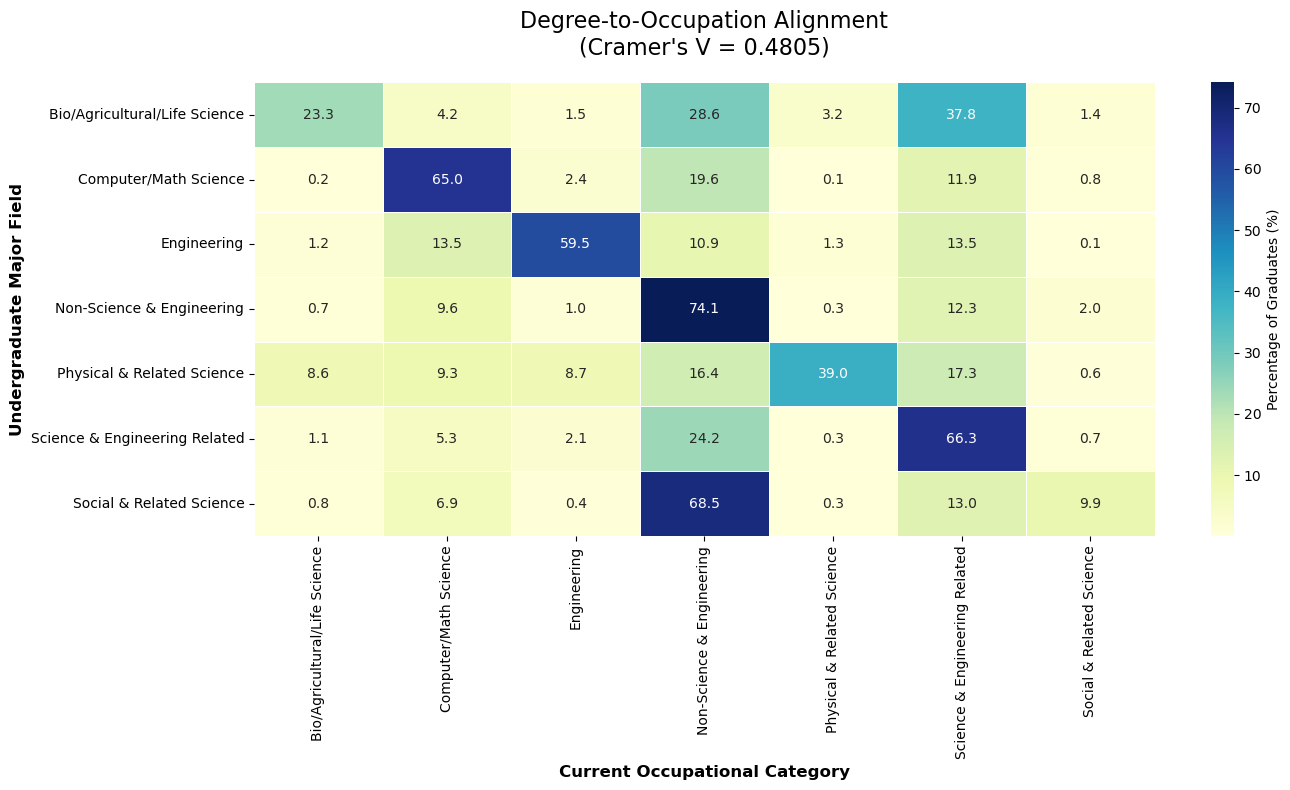

In [20]:
## EDA1 Plot
## normalized crosstab(row-wise percentage)
## "Of those who studied X, what % are in job Y?"

tb_norm = pd. crosstab(
    df_eda1['Major_Category'],
    df_eda1['Job_Category'],
    normalize='index'
) * 100

## initalize the figure and axes for format
fig, ax = plt.subplots(figsize=(14,8))
sns.heatmap(
    tb_norm,
    annot = True,
    fmt = ".1f",
    cmap = "YlGnBu",
    linewidths = 0.5,
    cbar_kws = {'label': 'Percentage of Graduates (%)'},
    ax = ax
)

## Label Axis and title
ax.set_title(f'Degree-to-Occupation Alignment\n(Cramer\'s V = 0.4805)', fontsize=16, pad=20)
ax. set_ylabel(f'Undergraduate Major Field', fontsize=12, fontweight='bold') 
ax.set_xlabel(f'Current Occupational Category', fontsize=12, fontweight='bold')

## rotate labels for better readability plt.xticks(rotation=45, ha='right' )
plt.yticks(rotation=0)
plt.tight_layout()

os.makedirs('../results/EDA1_figs', exist_ok=True)
plt.savefig('../results/EDA1_figs/degree-to-occupation.png', dpi=150, bbox_inches='tight')
plt.show()